# Chapter 25: Improving an Agent Without Trusting the Improvement

An improvement search produces several promising procedures. One wins development evaluation, but its apparent gain may come from adaptation to that development set. Release needs a different question: how does the frozen winner perform on evidence that did not help select it?

This notebook separates development selection from a guard comparison. The default development winner fails the release threshold, while another candidate looks better on guard. That temptation is deliberate. Switching winners after inspecting guard results would use the guard for selection and break the clean protocol. The transfer case makes contamination explicit rather than treating a favorable held-out number as certification.

**Outcome:** Select on development and check only the frozen winner against a declared guard contract.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

For candidate c, development rate is the mean of its binary development outcomes. The selected candidate maximizes that rate, with input order resolving ties. Guard outcomes are aligned by position with the baseline guard. The selected gain is mean_i[Y_c,i-Y_baseline,i].

Acceptance requires gain at least the prespecified threshold and guard_reused=false. The threshold is a procedural rule, not a confidence bound. Finite sample noise can produce a pass even when the target-population gain is smaller. A statistical release rule would require additional assumptions, error control, and an appropriately reserved evaluation design.

The function reports every candidate's descriptive guard rate for teaching inspection, but the acceptance decision uses only the development-selected row. Those displayed guard results must not feed later candidate selection if the same evidence is to remain a clean guard. Repeated adaptive reuse changes its role. A boolean flag records that declared contamination boundary; it does not independently audit the history of a real experiment.

## A calculation you can run

Supply binary baseline guard outcomes, candidate development and guard vectors, minimum gain, and reuse status. Guard lengths must match the baseline; every observed outcome must be zero or one. Development samples need not share guard length because they serve a different purpose.

The function calculates development rates, freezes the winner, computes paired guard gains, and applies the acceptance contract. Separate figures show development selection and guard gains. In the default case, identify the winner before looking at the second plot. The changed case improves that winner's guard evidence without changing selection. The transfer case gives a favorable gain but declares prior reuse, so you can test whether contamination blocks a clean release claim.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 25
inputs = {'baseline_guard': [True, False, True, False],
 'minimum_guard_gain': 0.2,
 'guard_reused': False,
 'candidates': [{'name': 'flashy',
                 'development': [True, True, True, True],
                 'guard': [True, False, True, False]},
                {'name': 'steady',
                 'development': [True, True, True, False],
                 'guard': [True, True, True, False]}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 25: development-guard-gate
Should the development winner be accepted under a separate release guard?
Evidence: constructed teaching example

Calculated quantities:
{
  "selected_candidate": "flashy",
  "selected_guard_gain": 0.0,
  "release_accepted": false,
  "guard_contaminated": false,
  "baseline_guard_rate": 0.5
}

Interpretation:
Development selects one candidate. Only that frozen candidate meets the declared guard threshold, and a reused guard invalidates the clean-release claim.

Assumptions:
- Guard rows are paired with baseline by their position.
- Acceptance threshold is declared before observing guard outcomes.
- Guard is reserved for this single decision.

Limitations:
- Passing a finite gate is not certification or a confidence guarantee.
- Reporting every candidate's guard result requires keeping those results out of future selection.

Execution: completed locally; constructed inputs are not deployment measurements.


Flashy wins development at 1.0, above steady at 0.75. Flashy's default guard equals the baseline, so gain is 0 and release is rejected against threshold 0.2. Steady's guard gain is 0.25, but selecting it after seeing that result would turn guard into another development set.

In the changed case, flashy repairs one baseline failure, giving guard gain 0.25. It now meets the declared threshold and is accepted because the guard is not reused. That pass means the finite procedural gate passed. It does not establish a confidence guarantee or remove the need for reversible deployment and monitoring.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


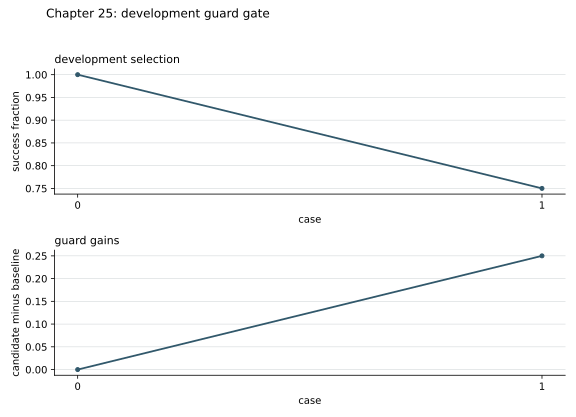

In [3]:
display(SVG(figure_svg(report)))

**Figure 25.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

The most direct contamination failure is choosing the candidate with the best guard score instead of the development winner. Another is repeatedly tuning a procedure after every failed guard result while continuing to call the same data untouched. Both make the guard participate in improvement.

The transfer case has a large favorable gain but guard_reused=true. The method rejects a clean release claim because the evidence no longer has its reserved role. The gain remains a descriptive quantity; contamination does not make arithmetic disappear.

A gate can also fail through undefined pairing or a post hoc threshold. Here positions define matched guard tasks, so the caller must preserve that meaning. Choose the threshold before inspecting outcomes and keep candidate, data, and procedure identifiers in the record. Passing this small deterministic rule is not certification of a generally improved agent.

Chapter 25: development-guard-gate
Should the development winner be accepted under a separate release guard?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "selected_candidate": "flashy",
  "selected_guard_gain": 0.25,
  "release_accepted": true,
  "guard_contaminated": false,
  "baseline_guard_rate": 0.5
}

Interpretation:
Development selects one candidate. Only that frozen candidate meets the declared guard threshold, and a reused guard invalidates the clean-release claim.

Assumptions:
- Guard rows are paired with baseline by their position.
- Acceptance threshold is declared before observing guard outcomes.
- Guard is reserved for this single decision.

Limitations:
- Passing a finite gate is not certification or a confidence guarantee.
- Reporting every candidate's guard result requires keeping those results out of future selection.

Execution: completed locally; constructed inputs are not deployment measurements.


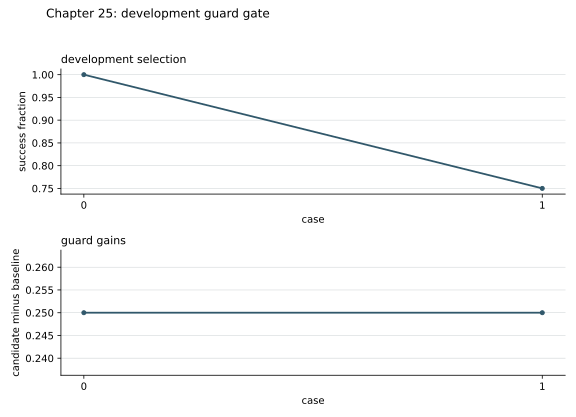

In [4]:
changed_inputs = {'baseline_guard': [True, False, True, False],
 'minimum_guard_gain': 0.2,
 'guard_reused': False,
 'candidates': [{'name': 'flashy',
                 'development': [True, True, True, True],
                 'guard': [True, True, True, False]},
                {'name': 'steady',
                 'development': [True, True, True, False],
                 'guard': [True, True, True, False]}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 25.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer proposal has guard success 1 compared with baseline 0.5, for gain 0.5. It exceeds threshold 0.1, but release remains rejected because the guard was reused. This separates favorable observed evidence from a valid acceptance protocol.

For local improvement work, freeze the candidate and its runtime before opening guard outcomes. Record the source of every prior evaluation and preserve a genuinely new guard after contamination. If uncertainty control is required, design that statistical rule explicitly rather than assigning a scientific meaning to a convenient numeric threshold. Keep rollback and monitoring outside the claim that the finite gate itself makes deployment safe.

In [5]:
transfer_inputs = {'baseline_guard': [False, True],
 'minimum_guard_gain': 0.1,
 'guard_reused': True,
 'candidates': [{'name': 'proposal', 'development': [True, True], 'guard': [True, True]}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 25: development-guard-gate
Should the development winner be accepted under a separate release guard?
Evidence: constructed transfer example

Calculated quantities:
{
  "selected_candidate": "proposal",
  "selected_guard_gain": 0.5,
  "release_accepted": false,
  "guard_contaminated": true,
  "baseline_guard_rate": 0.5
}

Interpretation:
Development selects one candidate. Only that frozen candidate meets the declared guard threshold, and a reused guard invalidates the clean-release claim.

Assumptions:
- Guard rows are paired with baseline by their position.
- Acceptance threshold is declared before observing guard outcomes.
- Guard is reserved for this single decision.

Limitations:
- Passing a finite gate is not certification or a confidence guarantee.
- Reporting every candidate's guard result requires keeping those results out of future selection.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **baseline_guard:** Nonempty binary baseline outcomes aligned with each candidate guard.
- **minimum_guard_gain:** Finite prespecified candidate-minus-baseline mean threshold.
- **guard_reused:** Exact boolean stating whether guard evidence influenced improvement or prior selection.
- **candidates:** Nonempty rows with name,development:binary list,guard:binary list matched to baseline_guard.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch25.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 25: development-guard-gate
Should the development winner be accepted under a separate release guard?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "selected_candidate": "proposal",
  "selected_guard_gain": 0.5,
  "release_accepted": false,
  "guard_contaminated": true,
  "baseline_guard_rate": 0.5
}

Interpretation:
Development selects one candidate. Only that frozen candidate meets the declared guard threshold, and a reused guard invalidates the clean-release claim.

Assumptions:
- Guard rows are paired with baseline by their position.
- Acceptance threshold is declared before observing guard outcomes.
- Guard is reserved for this single decision.

Limitations:
- Passing a finite gate is not certification or a confidence guarantee.
- Reporting every candidate's guard result requires keeping those results out of future selection.

Execution: completed locally; constructed inputs are not deployment measurements.


## Questions

1. Why not release steady by default?

2. What changed gain allows flashy to pass?

3. Does contamination erase observed gain?

Answers: [separate solutions](../solutions/ch25.md). Try the calculation before opening them.

## Summary

Development chooses the procedure; reserved guard evidence checks the frozen choice. The default winner fails, the changed winner passes a finite threshold, and the transfer gain cannot support clean acceptance after reuse. These distinctions prevent adaptation from masquerading as independent validation. The gate is an inspectable protocol under declared pairing and history, not certification. Preserve data roles, thresholds, and candidate identity before making a release claim.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-25-development-guard-gate`](../skills/maa-25-development-guard-gate/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 25.1

![Equation 25.1](../assets/math/90855c398446144e8c04.svg)

Names a proposed procedure version while keeping the underlying model parameters frozen.

`e_t` can lead to a change in `\phi`; it does not make a claim about a new value of `\theta`.

LaTeX source, preserved for inspection:

```latex
\phi'\in\mathcal M(\phi_t,e_t), \qquad
\theta_{t+1}=\theta_t.
\tag{25.1}
```

### Equation 25.2

![Equation 25.2](../assets/math/2ff671a2b70bfaa5ac25.svg)

Selects a development candidate, then defines its paired guard estimate.

Development chooses `\phi'`; the guard averages bounded parent-candidate differences after that choice is fixed.

LaTeX source, preserved for inspection:

```latex
\begin{aligned}
&\widehat\Delta_D(\phi_j)=\widehat V_D(\phi_j)-\widehat V_D(\phi_t),
\qquad \phi'=\arg\max_{\phi_j\in\Phi_t}\widehat\Delta_D(\phi_j),\\
&Z_i(\phi')\in[-1,1], \qquad
\widehat\Delta_G(\phi')=\frac{1}{m}\sum_{i=1}^{m}Z_i(\phi').
\end{aligned}
\tag{25.2}
```

### Equation 25.3

![Equation 25.3](../assets/math/1e15d3b9f1d8013a77bc.svg)

Bounds one fixed candidate's false acceptance and shows the stated ten-decision scale.

Both values depend on the frozen-candidate, bounded-outcome, and independent-guard assumptions.

LaTeX source, preserved for inspection:

```latex
\Pr\!\left(\widehat\Delta_G(\phi')\geq 0.25\right) \leq
\exp\!\left(-\frac{200(0.25)^2}{2}\right) \approx 0.00193
\quad\text{for every fixed }\phi'\text{ with }\Delta(\phi')\leq0,
\qquad 10(0.00193)\approx0.0193.
\tag{25.3}
```

### Equation 25.4

![Equation 25.4](../assets/math/ee5d22fff351da35d73c.svg)

Admits a procedure version only when uplift, cost, authority, and rollback each pass their own test.

A high uplift cannot compensate for missing authority or an untested return path.

LaTeX source, preserved for inspection:

```latex
\operatorname{accept}(\phi')=1 \iff \begin{cases}
\widehat\Delta_G(\phi')\geq\tau,\\
\widehat C_G(\phi')\leq c-\varepsilon_{\mathrm{safe}},\\
\operatorname{Authorized}_{\mathcal G}(\phi')=1,\\
\operatorname{Rollback}(\phi',\phi_t)=1.
\end{cases}
\tag{25.4}
```